In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.compose import ColumnTransformer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
df = pd.read_csv("Loan_Default.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [3]:
from pandas.core.arrays import categorical
target = "Status"

df["Status"] = df["Status"].astype(str).str.strip().astype(int)
X = df.drop(columns=[target])
y = df[target].values

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns

preprocess = ColumnTransformer([
    ("cat",OneHotEncoder(handle_unknown="ignore", sparse_output=False),categorical_cols),
    ("num",StandardScaler(), numeric_cols)
])

X_processed = preprocess.fit_transform(X)
X_processed = np.array(X_processed, dtype=np.float32)
X_processed = np.nan_to_num(X_processed, nan=0.0)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,y,test_size=0.2,random_state=42
)

X_train = torch.tensor(X_train.toarray() if hasattr(X_train,"toarray") else X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)

X_test = torch.tensor(X_test.toarray() if hasattr(X_test,"toarray") else X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

train_loader = DataLoader(TensorDataset(X_train,y_train), batch_size=32,shuffle=True)

In [4]:
class MLP(nn.Module):
  def __init__(self,input_dim):
    super(MLP,self).__init__()
    self.model = nn.Sequential(
        nn.Linear(input_dim,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,1),
        nn.Sigmoid()
    )
  def forward(self, x):
    x = torch.nan_to_num(x, nan=0.0)
    out = self.model(x)
    out = torch.clamp(out, 1e-7, 1-1e-7)
    return out

model = MLP(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
epochs = 30
train_losses = []

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_x)
        outputs = torch.clamp(outputs, min=1e-7, max=1-1e-7)

        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/30, Loss: 0.0538
Epoch 2/30, Loss: 0.0073
Epoch 3/30, Loss: 0.0039
Epoch 4/30, Loss: 0.0043
Epoch 5/30, Loss: 0.0032
Epoch 6/30, Loss: 0.0020
Epoch 7/30, Loss: 0.0017
Epoch 8/30, Loss: 0.0020
Epoch 9/30, Loss: 0.0021
Epoch 10/30, Loss: 0.0011
Epoch 11/30, Loss: 0.0022
Epoch 12/30, Loss: 0.0019
Epoch 13/30, Loss: 0.0006
Epoch 14/30, Loss: 0.0022
Epoch 15/30, Loss: 0.0008
Epoch 16/30, Loss: 0.0010
Epoch 17/30, Loss: 0.0013
Epoch 18/30, Loss: 0.0014
Epoch 19/30, Loss: 0.0014
Epoch 20/30, Loss: 0.0014
Epoch 21/30, Loss: 0.0014
Epoch 22/30, Loss: 0.0009
Epoch 23/30, Loss: 0.0008
Epoch 24/30, Loss: 0.0008
Epoch 25/30, Loss: 0.0008
Epoch 26/30, Loss: 0.0009
Epoch 27/30, Loss: 0.0019
Epoch 28/30, Loss: 0.0005
Epoch 29/30, Loss: 0.0007
Epoch 30/30, Loss: 0.0011


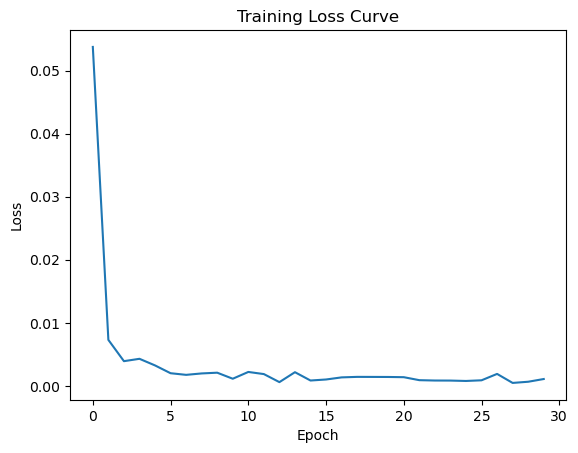

In [6]:
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Accuracy: 0.9983520548866618
Precision: 0.9934129271305063
Recall: 0.9998618784530386
F1 Score: 0.9966269704687822
Confusion Matrix:
 [[22446    48]
 [    1  7239]]


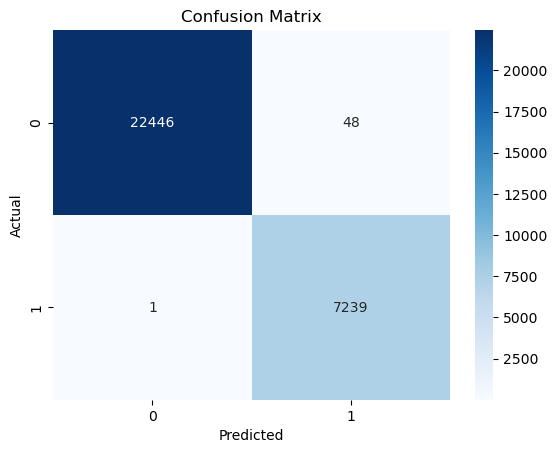

In [7]:
with torch.no_grad():
    y_pred = model(X_test)
    y_pred_cls = (y_pred > 0.5).float()

accuracy = accuracy_score(y_test, y_pred_cls)
precision = precision_score(y_test, y_pred_cls)
recall = recall_score(y_test, y_pred_cls)
f1 = f1_score(y_test, y_pred_cls)

cm = confusion_matrix(y_test, y_pred_cls)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()